---
title: "Design of Experiments"
author: "Nick Gould"
date: 2026-08-06
categories:
  - experimentation
  - statistics
  - data-science
jupyter: python3
---

[![](https://imgs.xkcd.com/comics/correlation.png)](https://xkcd.com/552/)

## Design of Experiments

### What is a DoE?

* A [**Design of Experiments**](https://en.wikipedia.org/wiki/Design_of_experiments) (abbreviated DoE) is a method for systematically varying factors to evaluate their effect on a response
* A DoE uses concepts from statistics, probability, linear algebra, geometry, and calculus to try to maximize the amount of information that can be obtained with the minimum number of experiments
* Much like how you don’t have to understand how an engine or transmission works to drive a car, you don’t have to understand all the math behind a DoE to perform or analyze a DoE

### Terminology

* A **factor** is an independent variable being changed.  It can be continuous (like temperature or concentration) or categorical (specific reagent).
* A **response** is a dependent variable being measured.  It can also be continuous or categorical.
* A **main effect** is a linear effect of a factor on the response
  * For example: Doubling the concentration of a reagent doubles the yield
* An **interaction term** is an effect where two factors affect a response together
  * For example: Month of the year and outside temperature have an interaction with ice cream sales, typically there are more sales of ice cream on hot days in the summer than the winter (even if the Cornell Dairy Bar is delicious year-round)
* A **squared term** is an effect where a factor has some curvature and possibly an optimum
  * For example: Enzymes typically work best at certain temperatures.  If the temperature is too low or two high, then the enzyme may not work properly
* **Higher order terms** exist (for example cubic terms), but you’re unlikely to run into those in a DoE
* **Design Resolution** describes what gets confounded (aliased) in a fractional design. The three you'll usually meet:
  * **III** — main effects are aliased with two-factor interactions
  * **IV** — main effects are clear of two-factor interactions, but the two-factor interactions are aliased with each other
  * **V** — main effects and two-factor interactions are all clear of one another (2-way interactions are aliased only with 3-way and higher terms)

### Selecting Terms and Conditions

Not to be confused with the check box you click before doing anything on a computer.

#### Selecting Factors and Responses

* To determine which factors influence a response, the conditions under which the factors are run should be as uncorrelated as possible
* For two factors, they are arranged in a square or rectangular grid (r^2^ = 0)
* If the factors are laid out in a different arrangement, it can be difficult to determine how much a factor affects a response during analysis
  * This becomes important later when trying to optimize the amount of information obtained using the minimum number of experiments

* The factors can be assigned to grid points
  * These form a +/- pattern
  * Continuous factors work
  * Categorical factors work
  * Mixing continuous and categorical factors also works 
  * These gridpoints define an n-dimensional hypercube, for example 2 factors form a square, 3 factors a cube, 4 factors a 4-D hypercube, etc.

If the factors are correlated, it becomes challenging to assign the cause of a response to one or another. Does your ice cream taste better because you added more cream or sugar? If you change both at once, it will be hard to tell.

![](../images/DoE_variance.png)

#### Subject Matter Expertise Matters

A DoE is not a blank check ignore known information, and these can be used to inform a design.

Examples:

* Enzymes are proteins that have a narrow band of temperatures where they will function properly. Human proteins work in a narrow band of temperatures in the upper 90s to low 100s F. Setting the boundary conditions becomes important and the results might be different for different organisms. Human digestive enzymes will want to be around 99F; heat shock proteins might prefer higher temperatures seen with a fever, exercise, or sauna use. Some species of fish live in arctic climates that would kill a human in minutes.
* Phase changes, if a DoE has bounds above and below the boiling point of water and there's water in the system, that might affect the results
* Material properties of components, a steam engine tends to be more efficient at higher temperatures. Steel has an upper temperature cutoff that could cause the engine to fail and thus require more exotic (read: expensive) materials, or a fuel might not be capable of generating enough heat and require a more expensive or harder to handle fuel.

### Types of DoEs

There are dozens of types of DoEs, but the main ones to know are:

* Full Factorial Design
* Fractional Factorial Design
* Response Surface Design
* Definitive Screening Design
* Mixture Design

#### Full Factorial

* A full factorial DoE does experiments on every corner of a design space.  For two factors it looks like a square, three factors a cube, etc.
* A 2^n^ full factorial DoE will give full resolution of all main effects and interaction terms
  * A 2^n^ full factorial DoE with a center point should detect if there's a squared term, but won't be able to assign it to which factor; adding a center point shouldn't mess up the geometry of a factorial DoE
* A 3^n^ full factorial DoE will give full resolution of all main effects, interaction terms, and squared terms
Full factorial DoE's are very expensive in terms of total experiments required

#### Fractional Factorial

* A fractional factorial DoE does experiments on every other corner of a design space. 
* Depending on its resolution, a fractional factorial can give clean main effects while confounding some interactions (Resolution IV or higher); a lower-resolution (III) fraction buys even fewer runs but aliases main effects with two-factor interactions
  * For example: it may be impossible to tell the difference between a response is caused by a Temperature and Stir Rate interaction, or a Concentration and Reaction Time interaction
* Fractional factorial DoE’s require half the number of experiments that a full factorial design requires, 2^n-1^ for n factors

#### Response Surface Design

* A Response Surface Design (RSM) builds on a factorial design by adding extra points specifically chosen to estimate squared terms, so it can detect curvature and locate an actual optimum instead of just a linear trend
* The two most common RSM designs are Central Composite Designs (CCD), which add axial ("star") points and center points to a factorial core, and Box-Behnken designs, which avoid the corners of the design space entirely
  * Box-Behnken designs are useful when the corners of a design space represent conditions that are impractical or unsafe to run, e.g. testing the highest temperature and highest pressure at the same time
* Response Surface Designs give full resolution of main effects, interactions, and squared terms, similar to a 3ⁿ full factorial, but require far fewer experiments to get there
* Response Surface Designs are typically run after a screening design or characterization step has already narrowed down which factors matter; adding curvature-detecting runs for a factor that turns out not to matter is a wasted experiment

#### Definitive Screening Design

* A definitive screening design (DSD) designs its runs so there is always some resolution between interactions, but never perfect resolution
  * This trade off in precision greatly reduces the number of experiments, but can reduce the accuracy of predictive models
* Definitive Screening Designs allow for squared terms
* Definitive Screening Designs can reduce the number of experiments required for more than 4 factors, when the exponential growth of factorial designs make experiments resource prohibitive
* If a design determines that all the factors are important, it becomes difficult to model more than the main effects

### Deciding on which DoE to run

In practice, these design types aren't really independent choices so much as stages of a single sequential experimentation strategy, often summarized as screen, characterize, optimize. Most real projects start with more candidate factors than anyone can afford to run a full factorial on, so the campaign begins with a screening design — a Definitive Screening Design or a low-resolution (III) fractional factorial — whose only job is finding which handful of factors actually matter, accepting confounded interactions and no curvature as the price of getting there cheaply. Once the vital few are identified, a higher-resolution fractional or full factorial characterizes them properly, resolving clean main effects and (resolution permitting) clean two-factor interactions. If the goal is to land on an optimum rather than just understand the system, and the characterization step hints at curvature, a Response Surface Design adds the runs needed to estimate squared terms and actually locate a maximum or minimum.

Mixture Designs sit outside this progression entirely; they describe formulation problems, where the factors are ingredient proportions that have to sum to 100%, rather than independently adjustable settings, so they need their own geometry rather than fitting into a screen-characterize-optimize story. 

Worth noting: the example analyzed on this page skips the screening stage entirely and jumps straight to a full factorial — a reasonable call when subject matter expertise (see above) already tells you which four factors matter, which is exactly the kind of judgment call that makes DoE more of a craft than a formula.



### Comparison of DoE run counts



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
from itertools import combinations
from pyDOE3 import ff2n

PlotWidth = 6

In [2]:
pd.DataFrame({'Number of Factors': {0: 2, 1: 3, 2: 4, 3: 5, 4: 6, 5: 7, 6: 8},
 '2n Full Factorial': {0: 4, 1: 8, 2: 16, 3: 32, 4: 64, 5: 128, 6: 256},
 '3n Full Factorial': {0: 9, 1: 27, 2: 81, 3: 243, 4: 729, 5: 2187, 6: 6561},
 'Fractional Factorial': {0: '', 1: 4, 2: 8, 3: 16, 4: 32, 5: 64, 6: 128},
 'Definitive Screening Design (JMP)': {0: '', 1: '', 2: 17, 3: 17, 4: 17, 5: 21, 6: 21},
 'Definitive Screening Design (Jones–Nachtsheim)': {0: '', 1: '', 2: 9, 3: 11, 4: 13, 5: 15, 6: 17}

  }).style.hide(axis='index')

Number of Factors,2n Full Factorial,3n Full Factorial,Fractional Factorial,Definitive Screening Design (JMP),Definitive Screening Design (Jones–Nachtsheim)
2,4,9,,,
3,8,27,4,,
4,16,81,8,17,9
5,32,243,16,17,11
6,64,729,32,17,13
7,128,2187,64,21,15
8,256,6561,128,21,17


**Important note:** Run order should be randomized. It's often easier for the person performing the experiment to knock out certain combinations of factors in blocks, but doing this could introduce uncontrolled factors like environmental conditions (the lab is hotter in the afternoon than the morning) or operational (the experimenter is better at performing the later experiments than the earlier ones)

Additionally, blocking is an option for other nuisance factors. For example, a 4 factor 2^n^ DoE with 16 runs, but only 4 equipment slots per day to run. Blocking these runs into groups of 4 can account for the effects of things like "Monday" or "Tuesday."

## Example of Generating a DoE in Python

Most DoE software packages have functionality to generate a DoE based on your needs. Here's an example of how one might generate a full factorial DoE varying 4 common reaction parameters using the pyDOE3 library.

In [3]:
design = ff2n(4)  # shape: (16, 4)

factors = ['Catalyst Charge', 'Temperature', 'Pressure', 'Concentration']
doe = pd.DataFrame(design, columns=factors)

# Map coded (-1/+1) levels to the actual engineering units used in
# the Box, Hunter & Hunter (1978) study, referenced below
level_map = {
    'Catalyst Charge': {-1: 10,  1: 15},
    'Temperature':      {-1: 220, 1: 240},
    'Pressure':         {-1: 50,  1: 80},
    'Concentration':    {-1: 10,  1: 12},
}

for factor, mapping in level_map.items():
    doe[factor] = doe[factor].map(mapping)

# Randomize run order
doe = doe.sample(frac=1, random_state=1729).reset_index(drop=True)
doe.index = doe.index + 1
doe.index.name = 'Run Order'

display(doe.reset_index())

,Run Order,Catalyst Charge,Temperature,Pressure,Concentration
0,1,10,220,50,10
1,2,10,220,80,10
2,3,15,240,80,10
3,4,15,220,80,12
4,5,10,240,80,12
5,6,10,240,50,10
6,7,15,220,50,10
7,8,10,220,50,12
8,9,15,220,80,10
9,10,15,220,50,12




## Example of a DoE Analysis

Here is a short example of using the [statmodels](https://www.statsmodels.org/stable/index.html) python library to analyze a DoE. This can also be done using commercial software like [JMP](https://www.jmp.com/en/home) or [Minitab](https://www.minitab.com/en-us/), or R. My personal preference would be to use JMP.

For this example, I'm going to use the dataset: [CAT/TEMP/PRES/CONC EFFECT ON CHEMICAL PROCESS CONVERSION YIELD
BOX, HUNTER & HUNTER (1978)](../data/boxconverter_4_16.dat), which is sort-of available from [NIST](https://www.itl.nist.gov/div898/education/datasets.htm) website, however they've moved things around at least once and broken links on me, so it's now mirrored.

### Importing the data into Python

Unfortunately the data aren't in a _super_ convenient format for importing or data analysis, so we need to do some work to get the data into a pandas dataframe.

In [4]:
columns = ['%Conversion', 'Catalyst Charge', 'Temperature', 'Pressure', 'Concentration', 'Run Order']
myDoE = pd.read_csv('../data/boxconverter_4_16.dat', skiprows=25, sep='\s+', names=columns, index_col=False)
display(myDoE)

,%Conversion,Catalyst Charge,Temperature,Pressure,Concentration,Run Order
0,71,-1,-1,-1,-1,8
1,61,1,-1,-1,-1,2
2,90,-1,1,-1,-1,10
3,82,1,1,-1,-1,4
4,68,-1,-1,1,-1,15
5,61,1,-1,1,-1,9
6,87,-1,1,1,-1,1
7,80,1,1,1,-1,13
8,61,-1,-1,-1,1,16
9,50,1,-1,-1,1,5


### Exploring the Design Space

It's not obvious from looking at the tables what kind of design it is. Sure, you can look at the run counts chart we just looked at, count the number of factors, and figure out that it's full factorial, but let's prove it.

We also need to replace the grid points of -1 and 1 with their actual values.

We will need to expand this table to include interactions and squared terms, and then look at their corrleations. To preserve the symmetry, we also need to center the interaction and squared terms by subtracting off the average value they take.

,%Conversion,Catalyst Charge,Temperature,Pressure,Concentration,Run Order,Catalyst Charge * Temperature,Catalyst Charge * Pressure,Catalyst Charge * Concentration,Temperature * Pressure,Temperature * Concentration,Pressure * Concentration,Catalyst Charge * Catalyst Charge,Temperature * Temperature,Pressure * Pressure,Concentration * Concentration
0,71,10,220,50,10,8,25.0,37.5,2.5,150.0,10.0,15.0,6.25,100.0,225.0,1.0
1,61,15,220,50,10,2,-25.0,-37.5,-2.5,150.0,10.0,15.0,6.25,100.0,225.0,1.0
2,90,10,240,50,10,10,-25.0,37.5,2.5,-150.0,-10.0,15.0,6.25,100.0,225.0,1.0
3,82,15,240,50,10,4,25.0,-37.5,-2.5,-150.0,-10.0,15.0,6.25,100.0,225.0,1.0
4,68,10,220,80,10,15,25.0,-37.5,2.5,-150.0,10.0,-15.0,6.25,100.0,225.0,1.0
5,61,15,220,80,10,9,-25.0,37.5,-2.5,-150.0,10.0,-15.0,6.25,100.0,225.0,1.0
6,87,10,240,80,10,1,-25.0,-37.5,2.5,150.0,-10.0,-15.0,6.25,100.0,225.0,1.0
7,80,15,240,80,10,13,25.0,37.5,-2.5,150.0,-10.0,-15.0,6.25,100.0,225.0,1.0
8,61,10,220,50,12,16,25.0,37.5,-2.5,150.0,-10.0,-15.0,6.25,100.0,225.0,1.0
9,50,15,220,50,12,5,-25.0,-37.5,2.5,150.0,-10.0,-15.0,6.25,100.0,225.0,1.0


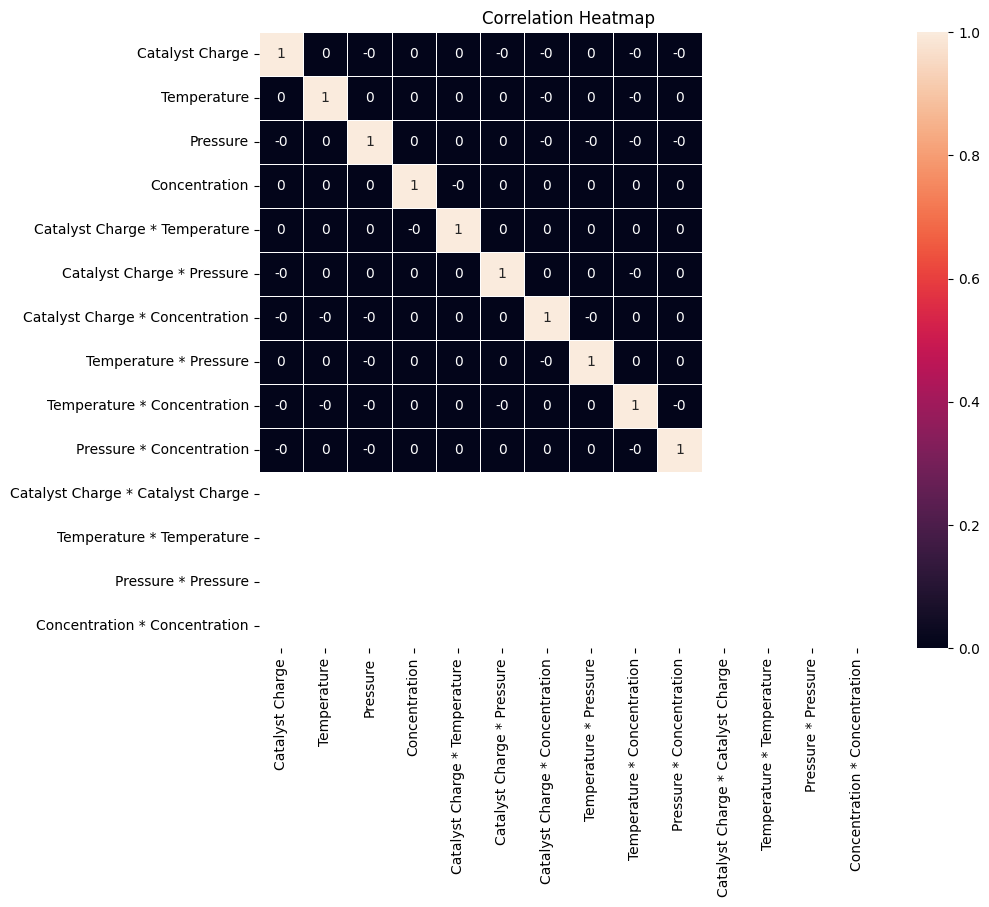

In [5]:
myDoE['Catalyst Charge'] = myDoE['Catalyst Charge'].replace([-1,1], [10,15])
myDoE['Temperature'] = myDoE['Temperature'].replace([-1,1], [220,240])
myDoE['Pressure'] = myDoE['Pressure'].replace([-1,1], [50,80])
myDoE['Concentration'] = myDoE['Concentration'].replace([-1,1], [10,12])

Factors = ['Catalyst Charge', 'Temperature', 'Pressure', 'Concentration']
Interactions = list(combinations(Factors, 2))

interactionCols = []
# interactions
for factorA, factorB in Interactions:
    interactionName = factorA + ' * ' + factorB
    myDoE[interactionName] = (myDoE[factorA] - myDoE[factorA].mean()) * (myDoE[factorB] - myDoE[factorB].mean())
    interactionCols.append(interactionName)

# squared terms

squaredCols = []
for factor in Factors:
    squaredName = factor + ' * ' + factor
    myDoE[squaredName] = (myDoE[factor] - myDoE[factor].mean()) ** 2
    squaredCols.append(squaredName)

display(myDoE)

plt.figure(figsize=(10,8))
sns.heatmap(np.round(myDoE[Factors + interactionCols + squaredCols].corr(), 2), linewidths=0.5, annot=True)
plt.title("Correlation Heatmap")
plt.show()

When we do this, we notice the correlations between each factor and every other factor, each factor and every interaction, and each interaction and every other interaction are all 0; everything is mutually orthogonal. 

The squared terms behave differently: in a two-level design each factor takes only two values, so once you center and square it, every run collapses to the *same* constant value. A constant column has zero variance, so its correlation is undefined (it shows up blank/NaN in the heatmap) and it's perfectly confounded with the intercept. This is why curvature can't be estimated from a two-level design. Because all main effects and two-factor interactions are mutually clear, this design is at least Resolution V; in fact, being a full factorial, nothing is aliased at all.

### Exploratory Data Analysis

Exploratory Data Analysis (EDA) is an important early step in any data analysis. It gives an idea of how the data are distributed and outliers become immediately apparent.

We're going to look at 3 plots:

* Box Plot
* Histogram
* Scatter Plot vs. Run Order

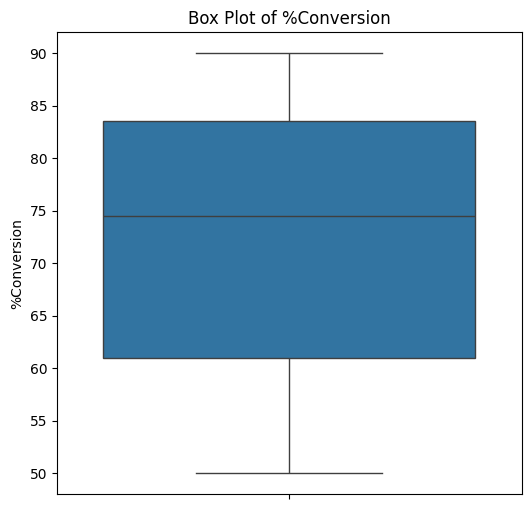

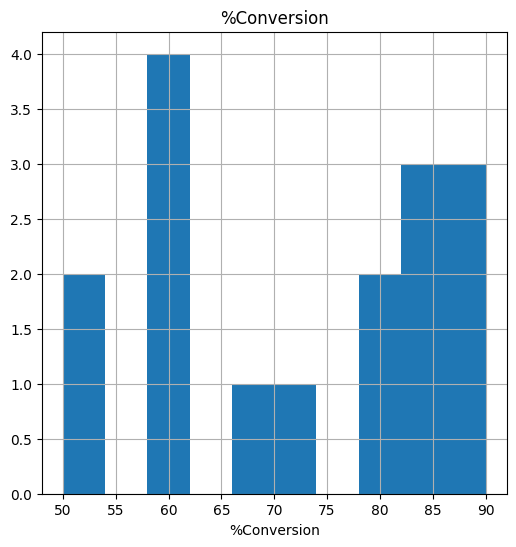

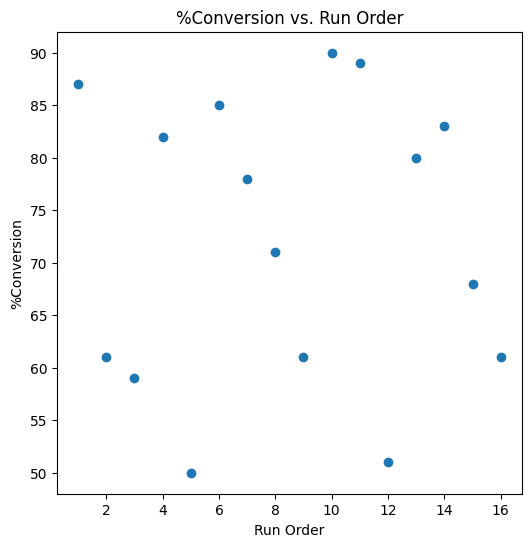

In [6]:
plt.figure(figsize=(PlotWidth, PlotWidth))
sns.boxplot(data=myDoE['%Conversion'])
plt.title('Box Plot of %Conversion')
plt.ylabel('%Conversion')
plt.show()

plt.figure(figsize=(PlotWidth, PlotWidth))
myDoE['%Conversion'].hist()
plt.title('%Conversion')
plt.xlabel('%Conversion')
plt.show()

plt.figure(figsize=(PlotWidth, PlotWidth))
plt.scatter(myDoE['Run Order'], myDoE['%Conversion'])
plt.title('%Conversion vs. Run Order')
plt.xlabel('Run Order')
plt.ylabel('%Conversion')
plt.show()



So it looks like all the conversion data are of the same order of magnitude and is not autocorrelated to the order in which it was run.

Using Statmodels, let's look at what the model looks like for our design space.

                            OLS Regression Results                            
Dep. Variable:            %Conversion   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.994
Method:                 Least Squares   F-statistic:                     232.9
Date:                Thu, 06 Aug 2026   Prob (F-statistic):           4.95e-06
Time:                        09:53:41   Log-Likelihood:                -14.856
No. Observations:                  16   AIC:                             51.71
Df Residuals:                       5   BIC:                             60.21
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

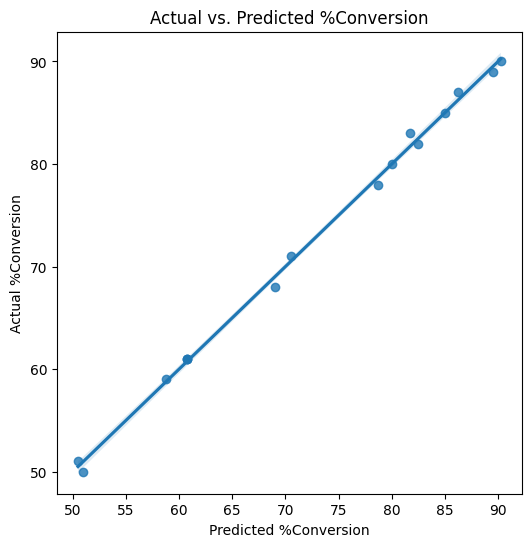

In [7]:
y = myDoE['%Conversion']
X = myDoE[Factors + interactionCols]

## An intercept is not added by default, so we need to add that here
X = sm.add_constant(X)
results = sm.OLS(y, X).fit()

print(results.summary())

plt.figure(figsize=(PlotWidth, PlotWidth))
sns.regplot(x=results.predict(X), y=y)
plt.xlabel('Predicted %Conversion')
plt.ylabel('Actual %Conversion')
plt.title('Actual vs. Predicted %Conversion')
plt.show()

### Identifying the active effects

With no replication we have no pure-error estimate, so the classic tool here is a **half-normal plot** of the effects (Daniel's method). Inactive effects fall along a line near the origin; active effects peel away to the upper right. Effects are computed in coded (−1/+1) units so their magnitudes are directly comparable.

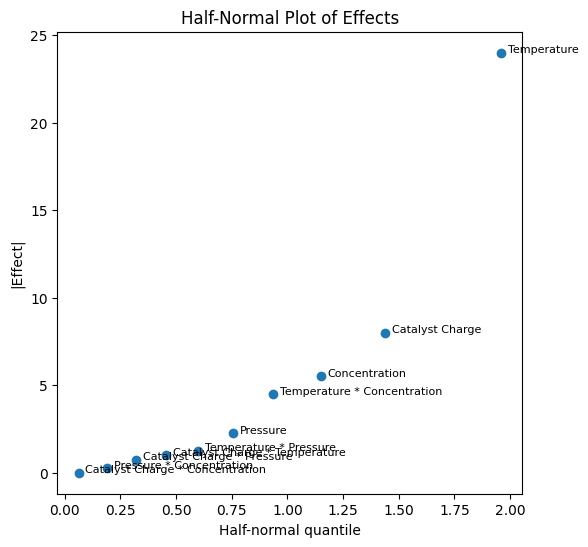

In [8]:
# Rebuild a coded (-1/+1) version of the design
code_map = {
    'Catalyst Charge': {10: -1, 15: 1},
    'Temperature':     {220: -1, 240: 1},
    'Pressure':        {50: -1, 80: 1},
    'Concentration':   {10: -1, 12: 1},
}
coded = pd.DataFrame({f: myDoE[f].map(code_map[f]) for f in Factors})

# Add all two-factor interactions as products of coded columns
for a, b in combinations(Factors, 2):
    coded[f'{a} * {b}'] = coded[a] * coded[b]

Xc = sm.add_constant(coded)
coded_fit = sm.OLS(myDoE['%Conversion'], Xc).fit()

# Effect = 2 * coefficient in coded units; drop the intercept, sort by magnitude
effects = (2 * coded_fit.params.drop('const')).sort_values(key=np.abs)
abs_effects = effects.abs().values
labels = effects.index

# Half-normal quantiles for the ordered absolute effects
n = len(abs_effects)
ranks = np.arange(1, n + 1)
quantiles = stats.norm.ppf(0.5 + 0.5 * (ranks - 0.5) / n)

plt.figure(figsize=(PlotWidth, PlotWidth))
plt.scatter(quantiles, abs_effects)
for x, y, lbl in zip(quantiles, abs_effects, labels):
    plt.annotate(lbl, (x, y), textcoords='offset points', xytext=(5, 0), fontsize=8)
plt.xlabel('Half-normal quantile')
plt.ylabel('|Effect|')
plt.title('Half-Normal Plot of Effects')
plt.show()

Not all the terms matter. We could remove terms doing [Stepwise Regression](https://en.wikipedia.org/wiki/Stepwise_regression), one at a time. 

We could also observe that the interaction between catalyst charge and concentration, catalyst charge and pressure, and pressure and concentration have high p-values. These can be dropped from the model.

Catalyst Charge * Concentration has a coefficient that is about as close to 0 as machine precision would allow, effectively ruling out it as an effect.

The half-normal plot separates the active effects from the inactive ones, which is a nice check. 

We will also keep the interaction term for catalyst charge and temperature despite p=0.088. This is a borderline case and future experiments might want to account for it to decide if it's real or not.

                            OLS Regression Results                            
Dep. Variable:            %Conversion   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.994
Method:                 Least Squares   F-statistic:                     375.5
Date:                Thu, 06 Aug 2026   Prob (F-statistic):           1.98e-09
Time:                        09:53:41   Log-Likelihood:                -17.643
No. Observations:                  16   AIC:                             51.29
Df Residuals:                       8   BIC:                             57.47
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

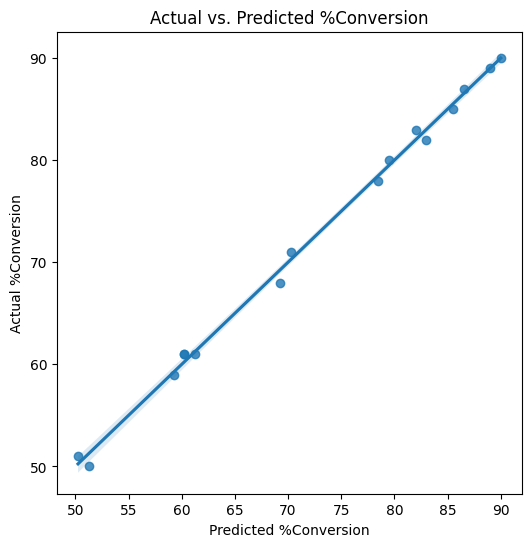

In [9]:
y = myDoE['%Conversion']
X = myDoE[['Catalyst Charge', 'Temperature', 'Pressure', 'Concentration', 'Catalyst Charge * Temperature', 'Temperature * Pressure', 'Temperature * Concentration']]

## An intercept is not added by default, so we need to add that here
X = sm.add_constant(X)
results = sm.OLS(y, X).fit()

print(results.summary())

plt.figure(figsize=(PlotWidth, PlotWidth))
sns.regplot(x=results.predict(X), y=y)
plt.xlabel('Predicted %Conversion')
plt.ylabel('Actual %Conversion')
plt.title('Actual vs. Predicted %Conversion')
plt.show()

### Checking the residuals

Before trusting the model, check its residuals: no structure in residuals-vs-fitted (constant variance), points along the line in the Q-Q plot (approximate normality), and no drift in residuals-vs-run-order (independent errors).

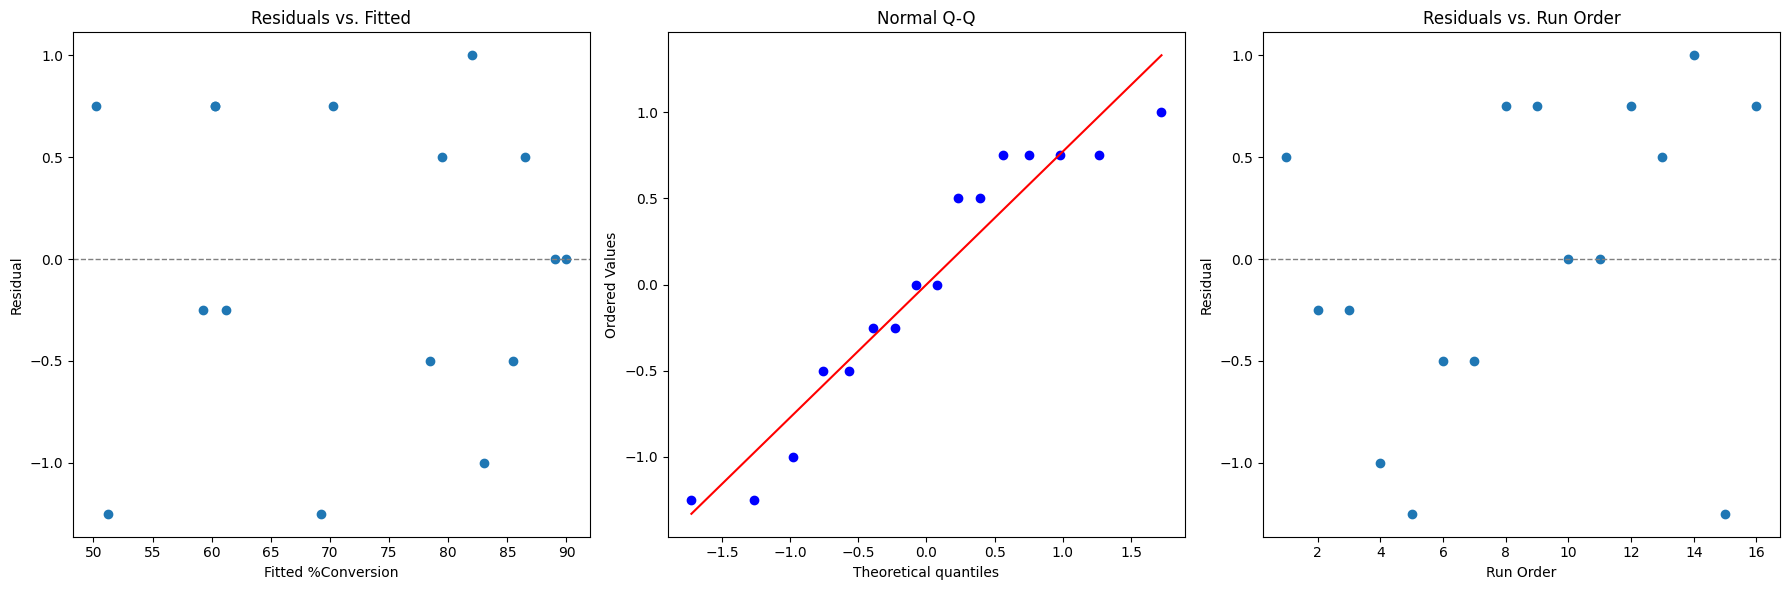

In [10]:
resid = results.resid
fitted = results.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(3 * PlotWidth, PlotWidth))

axes[0].scatter(fitted, resid)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[0].set_xlabel('Fitted %Conversion')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs. Fitted')

stats.probplot(resid, dist='norm', plot=axes[1])
axes[1].set_title('Normal Q-Q')

axes[2].scatter(myDoE['Run Order'], resid)
axes[2].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[2].set_xlabel('Run Order')
axes[2].set_ylabel('Residual')
axes[2].set_title('Residuals vs. Run Order')

plt.tight_layout()
plt.show()

### Optimizing the Model

Now that we have a model we're satisfied with, we can optimize for the conditions that give the highest conversion. Since we can't detect curvature (and the coefficients aren't all 0), the optimum sits at one of the corners of our 4-D hypercube. Because a full factorial includes every corner, evaluating the model at the design points is enough to find it. If the true optimum lay in the interior of the design space, we'd need curvature-detecting runs (a response surface design) to locate it.

If the model did contain curvature, we'd do more work using scipy's optimize functionality.

In [11]:
myDoE['%Conversion [Predicted]'] = results.predict(X)

# Settings at the run with the highest predicted conversion (the optimal corner),
# not the column-wise max of each factor independently.
best_idx = myDoE['%Conversion [Predicted]'].idxmax()
display(myDoE.loc[[best_idx], ['%Conversion [Predicted]'] + Factors])

,%Conversion [Predicted],Catalyst Charge,Temperature,Pressure,Concentration
2,90.0,10,240,50,10


## Additional Resources
* [Statistical Thinking for Industrial Problem Solving (STIPS)](https://www.jmp.com/en/online-statistics-course)
  * Put together by JMP, it uses their proprietary software, though in principle everything could be done with Excel, Python, an an abacus. If someone from JMP does read this and wants to get me a free or deeply discounted license for personal use, my contact info is at the top of this page.
* [Crash Course Statistics](https://www.youtube.com/playlist?list=PL8dPuuaLjXtNM_Y-bUAhblSAdWRnmBUcr)
  * 45 10-12 minute video series covering basic statistics to machine learning